<h1 style=font-size:30px> DATASCI 151 Final Project </h1>
<p style=font-size:20px>By Emily Gu (2674585), Tianshu Hu (2673827), Yiran Tao (2668350), Larissa Yue (2615811)</p>
<h2>Introduction</h2>

<b style=font-size:20px>Question: Does the Relative Age Effect (RAE) affect the Overall and Potential scores of female FIFA players?</b>
<p style=font-size:20px >The Relative Age Effect (RAE) refers to the phenomenon where children born in the first quarter of the year are more likely to have an advantage when they audition for sports teams. This is because children born in the first quarter are typically among the oldest among their peers, which means they are more physically and emotionally mature than the rest of their cohort. Therefore, we wanted to investigate the validity of the effect and determine whether soccer players born in the first quarter of the year have higher performance (Overall and Potential) scores compared to those born later in the year. These ratings are derived from the player evaluation system used in the EA Sports FC video game and compiled by databases such as SoFIFA, which aim to approximate real-world player ability and future development. This approach can help us determine whether the developmental advantages from childhood would persist into adulthood or if the competitive differences would eventually balance out. </p>

<p style=font-size:20px>From our analyses of the female player's Overall and Potential scores, we did not find any significant difference between the months and the score. This may suggest that the RAE does not persist into the athlete's careers in adulthood.</p>


<h2>Data Description</h2>

<p style=font-size:20px>For our project we used the csv files "female_players_16.csv" through "female_players_22.csv". Each row represents a unique female soccer player and their corresponding information presented in the columns. In the 2016 file, there are a total of 248 observations (rows) and 110 columns, which contained information, such as their name, soFIFA ID, as well as their Overall and Potential score for that year. </p>

 <p style=font-size:20px>Our goal was to find the average overall and potential scores of each female athlete across the years 2016 to 2022 in order to obtain a more representative measure of their performance, reducing the influence of year-to-year fluctations. Hence, we merged the csv files "female_players_16.csv" through "female_players_22.csv", and aggregated the data to contain their average overall and potential score across 2016 to 2022. This process retained the players that were active during the entirety of 2016-2022, which left us with 248 rows (meaning 248 players). Then, we assigned another column that assigned each player a birth-month range (Jan-Mar, Apr-Jun, Jul-Sep, Oct-Dec). For the final dataframe, we had 248 rows, and 4 columns that contained each player's soFIFA ID, average Overall score and the average Potential score across 2016-2022, and their assigned birth-month range. </p>

In [1]:
# import packages
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")


In [2]:
# Read in files
years = [16, 17, 18, 19, 20, 21, 22]
df_list = []
base_path = "2-FIFA/"

for y in years:
    file = base_path + "female_players_" + str(y) + ".csv"
    df = pd.read_csv(file)
    df_list.append(df)

<p style=font-size:23px>Merging procedure</p>

<p style=font-size:20px>First, from each csv file, only the relevant columns -- "sofifa_id", "overall", "potential", and "dob" -- were retained. </p>

In [3]:
# Keep only needed columns
cols = ["sofifa_id", "overall", "potential", "dob"]

for i in range(len(df_list)):
    df_list[i] = df_list[i][cols]

<p style=font-size:20px>Next, the variables that measure athelete performance ("overall" and "potential") were renamed by appending the corresponding year to prepare for later averaging</p>

In [4]:
# Rename column names for later averaging
for i in range(len(df_list)):
    y = years[i]
    
    df_list[i] = df_list[i].rename(columns={"overall": "overall" + str(y),"potential": "potential" + str(y)})

<p style=font-size:20px>Before merging, the 2016 dataframe was set as the primary dataframe. To avoid duplication of the overlapping "dob" variable, the "dob" columns were dropped from the remaining dataframes. During merging, the dataframes are joined on the shared column "sofifa_id". After merging, the resulting dataframe only includes players who played consistently from 2016 to 2022.</p>

In [5]:
# Set 2016 as the primary dataframe
df_merge = df_list[0]

# Keep dob only in first dataframe to avoid overlapping
for i in range(1, len(df_list)):
    df_list[i] = df_list[i].drop(columns="dob")

# Merge
for i in range(1, len(df_list)):
    df_merge = pd.merge(left=df_merge,right=df_list[i],how="left",on="sofifa_id")



<p style=font-size:23px>Cleaning procedure</p>

 <p style=font-size:20px>First, the "overall" and "potential" columns across all years were averaged to create two new columns "avg_overall" and "avg_potential", which represent the average performance of each player. </p>

In [6]:
# Compute average overall and potential

# Organize columns
overall_cols = []
potential_cols = []

for y in years:
    overall_cols.append("overall" + str(y))
    potential_cols.append("potential" + str(y))

# Create new columns
df_merge["avg_overall"] = df_merge[overall_cols].mean(axis=1)
df_merge["avg_potential"] = df_merge[potential_cols].mean(axis=1)

 <p style=font-size:20px>Next, the "dob" column was inspected for missing values and format. After confirming that all "dob" entries are consistent in the "year-month-date" structure, each "dob" entry was split into three strings using hyphens. Then, the revised "dob" column was checked again to ensure that all entires follow the "year", "month", "date" structure.  
 
 <p style=font-size:20px>After that, the second component from each entry was extracted to create a new column called "month" to represent the birth month of each player. </p></p>

In [7]:
# Extract months from dob column

# Are there any missing values?
print("Number of missing values:",df_merge["dob"].isna().sum())
# 0 - No

# Convert dob column to datetime format
df_merge["dob"] = pd.to_datetime(df_merge["dob"], format='%Y-%m-%d')

# Does conversion produce bad values?
print("Number of bad values:",df_merge["dob"].isna().sum())
# 0 - No

# Extract month
df_merge["month"] = df_merge["dob"].dt.month

Number of missing values: 0
Number of bad values: 0


 <p style=font-size:20px>These months are grouped into four categories: "jan-mar", "apr-jun", "jul-sep", and "oct-dec", and stored in a new column called "month_group". </p>

In [8]:
# Group months
# Group months
bins = [0, 3, 6, 9, 12]
labels = ["jan-mar", "apr-jun", "jul-sep", "oct-dec"]

df_merge["month_group"] = pd.cut(df_merge["month"],
                                bins=bins,
                                labels=labels,
                                right=True)

 <p style=font-size:20px>Finally, the final dataframe only retained relevant variables: "sofifa_id", "avg_overall", "avg_potential", and "month_group".</p>

In [9]:
# Final cleaning
df_final = df_merge[["sofifa_id", "avg_overall", "avg_potential", "month_group"]]

# Round all numbers to 2 decimal points
df_final = df_final.round(2)

display(df_final.head())

,sofifa_id,avg_overall,avg_potential,month_group
0,226324,89.5,89.5,jul-sep
1,226328,91.0,91.0,jul-sep
2,226334,90.0,90.0,apr-jun
3,226362,90.0,90.0,jan-mar
4,226373,89.0,89.0,apr-jun


<br>
<h2>Results</h2>
<p style=font-size:20px>In the original datasets, each player is assigned an overall rating from 0 to 99 based on a weighted combination of attributes that depend on the player’s position in Career Mode from FIFA 15 to FIFA 23. In the cleaned dataset, each player is associated with an average overall rating across years.</p>

<p style=font-size:20px>We also looked at each players' potential, which is assigned a number from 0 to 99. In the FIFA game, the potential indicates how good the player can become in the future, so the higher the potential, the better the player. </p>

<p style=font-size:20px>First, we will plot the mean of players' average overall and potential ratings by birth month group which categorizes the players into four quarters of the year.</p>

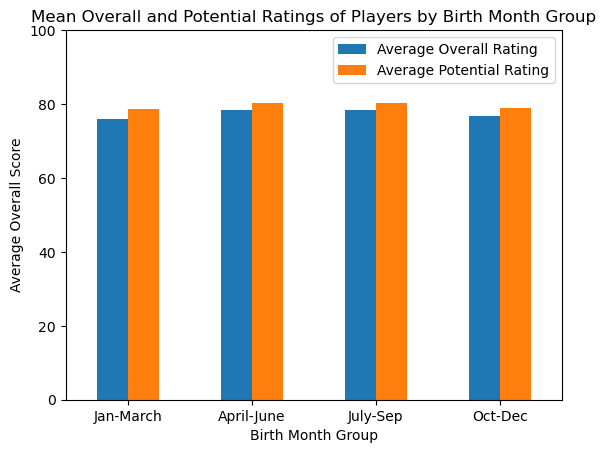

In [10]:
#Ordering birthday month groups based beginning to end of year
order = ["jan-mar", "apr-jun", "jul-sep", "oct-dec"]
df_final["month_group"] = pd.Categorical(
    df_final["month_group"],
    categories = order,
    ordered = True)

# Calculate the mean average overall and average potential rating for each month group
month_avg = df_final.groupby("month_group")[["avg_overall", "avg_potential"]].mean()

# Create bar graph of each birth month group's mean overall and potential rating 
month_avg.plot(kind = "bar")
plt.title("Mean Overall and Potential Ratings of Players by Birth Month Group")
plt.xlabel("Birth Month Group")
plt.ylabel("Average Overall Score")
plt.ylim(0, 100)
plt.xticks(rotation = 0, ticks = [0,1,2,3], labels = ["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
plt.legend(["Average Overall Rating", "Average Potential Rating"])
plt.show()

<p style=font-size:20px>After grouping players by birth month category and computing the mean of these average ratings, the resulting bar graph shows only small differences between groups for both the Overall and Potential variables. This indicates that average player ratings are relatively similar across birth month groups. Therefore, there is no clear evidence from this analysis that birth month is strongly associated with differences in player overall ratings and potential ratings.</p>

<p style=font-size:20px>Let's use a violin plot to show the full breakdown of each birth month group.</p>

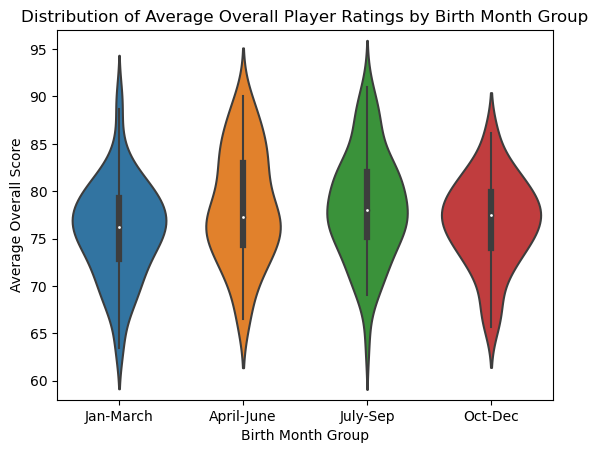

In [11]:
#Violin plot of each birthday month group's average overall score
sns.violinplot(x = "month_group", y = "avg_overall", data = df_final)
plt.title("Distribution of Average Overall Player Ratings by Birth Month Group")
plt.xlabel("Birth Month Group")
plt.ylabel("Average Overall Score")
plt.ylim(58, 97)
plt.xticks(ticks = [0,1,2,3], labels = ["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
plt.show()

<p style=font-size:20px>Because bar graphs only summarize the mean, we further analyzed whether there was any differences in distribution of players' average overall ratings within each birth month group. The violin plot displays the full distribution of values, including the spread, density, and range of ratings in each birth month group.</p>

<p style=font-size:20px>Across all four birth month groups, the shapes of the distributions appear very similar, with the median values and interquartile ranges closely aligned. This indicates that not only are the average ratings similar, but the variability of player ratings within each group is comparable as well. Overall, this suggests that there are no meaningful differences in the distribution of player ratings across birth month groups, further supporting the observation that birth month is not strongly associated with differences in player ability in this dataset.</p>

<p style=font-size:20px>Now, let's take a closer look at each of the birth month groups' average potential. In the FIFA game, there are four different statuses that a player can have depending on their potential rating:</p>

<p style=font-size:20px>"Has potential to be special": 91 and higher</p>
</br>
<p style=font-size:20px>"Exciting prospect": 86 - 90</p>
</br>
<p style=font-size:20px>"Showing great potential": 80 - 85</p>
</br>
<p style=font-size:20px>"At club since": less than 79</p>
</br>

<p style=font-size:20px>For conciseness, these statuses will be referred to respectively as: "Special", "Exciting", "Great", and "Lower". We will use a catplot ("categorical plot") from the Seaborn library to show the breakdown of potential statuses in for each birth month group.</p>

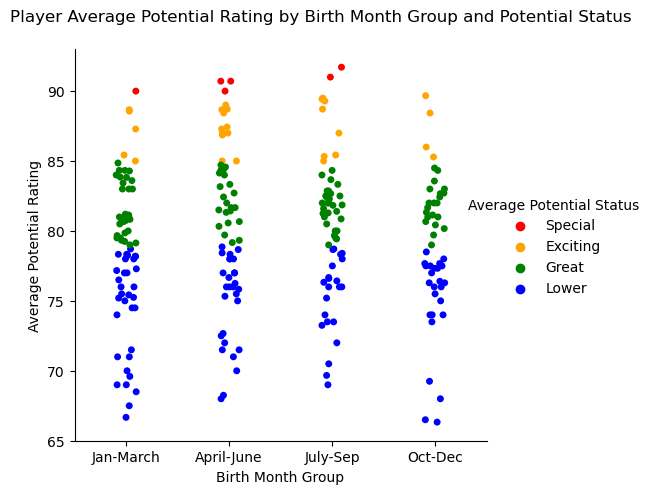

In [12]:
# Recode data into the potential statuses
potential_bins = [-np.inf, 79, 85, 90, np.inf]
potential_labels = ["Lower", "Great", "Exciting", "Special"]
df_final["avg_potential_status"] = pd.cut(x = df_final["avg_potential"], bins = potential_bins, labels = potential_labels, right = False)

# Plot using Seaborn catplot, indicating different potential statuses with different colors
g = sns.catplot(data = df_final, x = "month_group", y = "avg_potential", 
                hue = "avg_potential_status", 
                hue_order = ["Special", "Exciting", "Great", "Lower"],
                palette = {"Special":"red", "Exciting":"orange", "Great":"green", "Lower":"blue"})
g.axes[0,0].set_ylim(65, 93)
g.set_xticklabels(["Jan-March", "April-June", "July-Sep", "Oct-Dec"])
g.set_axis_labels("Birth Month Group", "Average Potential Rating")
g.figure.suptitle("Player Average Potential Rating by Birth Month Group and Potential Status")
g.figure.subplots_adjust(top=0.9)
g.legend.set_title("Average Potential Status")
plt.show()
# Note: The position of points in each birth month group is random and purely for aesthetic

<br>
<h2>Discussion</h2>

<p style=font-size:20px>To recall, our project wanted to investigate if the the RAE would extend into the professional careers of female soccer players. If the RAE had a noticeable impact on their careers, we likely would have observed a difference in the Overall and Potential scores between the age groups, where those born earlier in the year (Jan-Mar) would have higher average scores than those born later in the year (Oct-Dec).</p>
<p style=font-size:20px>However, our results provided no meaningful evidence that there is a RAE among female soccer players. The birth-month groups showed similar average Overall and Potential scores, and had similar distribution within each birth-month. Hence, the birth month does not seem to have any significant effects on player's skills. This seems to suggest that early developmental effects likely evens out with time, or that their skills are more influenced by other factors. </p>